# Классификация рентгенограмм туберкулёза с помощью свёрточных нейронных сетей

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Установка и загрузка библиотек](#1.1.)
<br>[1.2. Настройка локальной файловой системы](#1.2.)
<br>[1.3. Загрузка данных](#1.3.)
<br>[<b>Шаг 2. Подготовка данных</b>](#2)
<br>[2.1. Визуальный контроль качества данных](#2.1.)
<br>[2.2. Реализация кастомного класса датасета для PyTorch](#2.2.)
<br>[2.3. Разделение данных на обучающую и валидационную выборки](#2.3.)
<br>[<b>Шаг 3. Создание базовой модели</b>](#3)
<br>[3.1. Архитектура базовой модели](#3.1.)
<br>[3.2. Обучение базовой модели](#3.2.)
<br>[3.3. Сохранение базовой модели](#3.3.)
<br>[3.4. Предсказание на базовой модели](#3.4.)
<br>[3.5. Визуализация обучения базовой модели](#3.5.)
<br>[3.6. Оценка качества базовой модели](#3.6.)
<br>[<b>Шаг 4. Создание улучшенной модели</b>](#4)
<br>[4.1. Подготовка данных для улучшенной модели](#4.1.)
<br>[4.2. Архитектура с увеличением ёмкости и регуляризацией](#4.2.)
<br>[4.3. Обучение модели с Mixed Precision (AMP) и Cosine Annealing](#4.3.)
<br>[4.4. Сохранение улучшенной модели](#4.4.)
<br>[4.5. Предсказание на улучшенной модели](#4.5.)
<br>[4.6. Визуализация обучения улучшенной модели](#4.6.)
<br>[4.7. Оценка качества улучшенной модели](#4.7.)
<br>[<b>Вывод</b>](#5)

<a id=descr_proj></a>
## Описание проекта

Туберкулёз остаётся одной из наиболее острых проблем общественного здравоохранения как в мире, так и в Российской Федерации. Несмотря на значительный прогресс в фтизиатрии за последние десятилетия, заболевание продолжает представлять серьёзную угрозу, усугубляемую рядом социально-организационных факторов: сложностями организации массового скрининга, низкой приверженностью пациентов длительным схемам лечения и сохраняющейся стигматизацией больных. Эпидемиологические тенденции в России указывают на необходимость повышения диагностической настороженности, особенно в свете роста доли случаев с множественной (МЛУ-ТБ) и широкой (ХЛУ-ТБ) лекарственной устойчивостью, что существенно осложняет терапию, увеличивает сроки лечения и ухудшает общие прогнозы.

Современные протоколы диагностики активно дополняются высокочувствительными методами, такими как ПЦР, тестирование Xpert MTB/RIF и компьютерная томография высокой резолюции. Тем не менее, внедрение искусственного интеллекта в фтизиатрию становится критически важным направлением развития. Одной из ключевых проблем ИИ-диагностики является проведение точной дифференциальной диагностики туберкулёза от других патологий лёгких со схожей рентгенологической картиной, таких как пневмония, саркоидоз или онкологические заболевания. Автоматизированные системы компьютерной диагностики (CAD) на базе алгоритмов машинного обучения уже активно интегрируются в российскую систему здравоохранения для массового скрининга флюорограмм и анализа КТ, помогая врачам выявлять инфильтраты, каверны и очаговые изменения на самых ранних стадиях.

В этом контексте использование методов глубокого обучения, и в первую очередь свёрточных нейронных сетей (CNN), представляет собой наиболее передовой и перспективный подход к автоматизированной классификации рентгенограмм органов грудной клетки.  В отличие от КТ, где мы имеем дело с 3D-срезами и единицами Хаунсфилда, рентгенография (рентген ОГК) — это 2D-проекция, где все органы грудной клетки (ребра, ключицы, сердце, сосуды) накладываются друг на друга. Это создает колоссальный «анатомический шум».

Свёрточные сети обладают уникальной способностью извлекать иерархические пространственные признаки из медицинских изображений, обучаясь распознавать малозаметные паттерны туберкулёза, текстуры и морфологические аномалии, характерные для туберкулёзного процесса: очагах, инфильтратах, кавернах и плевральных выпотах. Благодаря применению архитектур, оптимизированных для задач компьютерного зрения, такие модели демонстрируют высокую чувствительность и специфичность, выступая в роли надёжного «второго мнения» для врачей-рентгенологов и существенно снижая диагностическую нагрузку и риск человеческой ошибки в условиях большого потока исследований.

<a id=descr_data></a>
## Описание данных

Для обеспечения надёжности и обобщающей способности модели классификации в данном исследовании используется агрегированный набор данных рентгеновских снимков органов грудной клетки. Основу массива составляют известные открытые коллекции снимков из Шеньчжэня (Shenzhen) и Монтгомери (Montgomery), предоставляющие базовый набор подтверждённых случаев туберкулёза и здоровых контрольных изображений. Для устранения дисбаланса классов и дальнейшего обогащения обучающей выборки мы дополнили датасет 700 снимками с туберкулёзом и 700 случайно выбранными снимками здоровых пациентов из открытого набора данных (University, Doha, Qatar, and the University of Dhaka, Bangladesh), доступного на платформе Kaggle. Стратегическое объединение этих разнородных источников не только кратно увеличивает общий объём базы данных, но и привносит большую вариативность в условия съёмки, демографические характеристики пациентов и типы рентгенологического оборудования. В результате такая сбалансированная и репрезентативная выборка позволяет нейронной сети обучаться на более устойчивых и инвариантных признаках, что напрямую ведёт к повышению качества, точности и клинической применимости разрабатываемой системы классификации.

**Постановка задачи:** разработать и обучить свёрточную нейронную сеть на базе PyTorch для бинарной классификации рентгенограмм (Норма / Туберкулёз), проанализировать влияние доменной специфики на выбор аугментаций и достичь стабильного качества без переобучения.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек

In [1]:
# стандартные библиотеки
import gc                     # очистка памяти перед началом работы
import os                     # взаимодействие с операционной системой
import copy                   # копирование объектов (например, весов модели)
import random                 # генерация случайных чисел (например, фиксация seed для воспроизводимости)

# работа с данными и визуализация
import pandas as pd             # работа с табличными данными
import matplotlib.pyplot as plt # графики и визуализация результатов
from pathlib import Path        # кроссплатформенное управление путями (важно для локального ПК!)
from PIL import Image           # открытие, чтение и базовая обработка файлов изображений
import kagglehub                # скачивание датасетов напрямую с платформы Kaggle

# PyTorch и связанные модули
import torch                  # основная библиотека PyTorch
import torch.nn as nn         # создание архитектуры нейронных сетей (слои, функции потерь)
import torch.nn.functional as F # функциональный API для применения активаций (ReLU, softmax) и других операций
import torch.optim as optim   # алгоритмы оптимизации (Adam, SGD и др.) для обновления весов
from torch.utils.data import Dataset, DataLoader, random_split # формирование, обработка пакетов данных и их разделение на train/val/test
from torchvision import transforms, models # аугментация данных, готовые предобученные архитектуры

# метрики оценки качества классификации
from sklearn.metrics import f1_score, precision_score, recall_score # (F1-score, точность, полнота)

print(f"Версия PyTorch: {torch.__version__}")
print(f"Доступность GPU: {torch.cuda.is_available()}")

Версия PyTorch: 2.5.1+cu121
Доступность GPU: True


### 1.2. Настройка локальной файловой системы

In [2]:
# создаём локальную структуру папок для проекта
PROJECT_DIR = Path("./lab_7_tb_xray_classification_CNN")
DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
print(f"Рабочая директория проекта: {PROJECT_DIR.absolute()}")

Рабочая директория проекта: C:\Users\Pellaero\2022 ПИШ\lab_7_tb_xray_classification_CNN


In [3]:
# создаём директории
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Директория для данных: {DATA_DIR.absolute()}")
print(f"Директория для сохранения весов: {CHECKPOINTS_DIR.absolute()}")

Директория для данных: C:\Users\Pellaero\2022 ПИШ\lab_7_tb_xray_classification_CNN\data
Директория для сохранения весов: C:\Users\Pellaero\2022 ПИШ\lab_7_tb_xray_classification_CNN\checkpoints


<a id=1.3.></a>
### 1.3. Загрузка данных

In [4]:
# автоматическая загрузка и агрегация датасетов через kagglehub
data_records = []

# загрузка датасетов Shenzhen и Montgomery
datasets_info = [
    {"name": "raddar/tuberculosis-chest-xrays-shenzhen", "csv_name": "shenzhen_metadata.csv", "source": "Shenzhen"},
    {"name": "raddar/tuberculosis-chest-xrays-montgomery", "csv_name": "montgomery_metadata.csv", "source": "Montgomery"}
]

for ds in datasets_info:
    print(f"\nЗагрузка: {ds['name']}")
    
    # kagglehub скачивает и распаковывает архив в локальный кэш
    path = Path(kagglehub.dataset_download(ds["name"]))
    csv_paths = list(path.rglob(ds['csv_name']))
    df_meta = pd.read_csv(csv_paths[0])
    all_images = {img.name.lower(): img for img in path.rglob("*.png")}
    
    matched = 0
    for _, row in df_meta.iterrows():
        filename = str(row['study_id']).strip().lower()
        findings = str(row['findings']).lower()
        
        if filename in all_images:
            img_path = all_images[filename]
            label = 0 if "normal" in findings else 1
            data_records.append({"image_path": str(img_path.absolute()), "label": label, "source": ds['source']})
            matched += 1
    print(f"Успешно сопоставлено: {matched} изображений для {ds['source']}")


Загрузка: raddar/tuberculosis-chest-xrays-shenzhen
Успешно сопоставлено: 662 изображений для Shenzhen

Загрузка: raddar/tuberculosis-chest-xrays-montgomery
Успешно сопоставлено: 138 изображений для Montgomery


In [5]:
# загрузка дополнительного датасета Tawsifurrahman
print("\nЗагрузка: tawsifurrahman/tuberculosis-tb-chest-xray-dataset")
tawsif_path = Path(kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset"))
all_tawsif_images = list(tawsif_path.rglob("*.png")) + list(tawsif_path.rglob("*.jpg")) + list(tawsif_path.rglob("*.jpeg"))

tb_images = []
normal_images = []

for img_path in all_tawsif_images:
    if "mask" in str(img_path).lower(): # пропускаем маски сегментации
        continue
    
    parent_folder = img_path.parent.name.lower()
    if "tuberculosis" in parent_folder or "tb" in parent_folder or "active" in parent_folder:
        tb_images.append(img_path)
    elif "normal" in parent_folder or "healthy" in parent_folder:
        normal_images.append(img_path)

print(f"   Найдено в Tawsifurrahman -> Туберкулёз: {len(tb_images)}, Норма: {len(normal_images)}")

# добавляем все изображения с туберкулёзом
for img_path in tb_images:
    data_records.append({"image_path": str(img_path.absolute()), "label": 1,  "source": "Tawsifurrahman_TB"})

# выбираем случайным образом 700 нормальных снимков для сохранения баланса
random.seed(42)
selected_normal = random.sample(normal_images, min(700, len(normal_images)))

for img_path in selected_normal:
    data_records.append({"image_path": str(img_path.absolute()),"label": 0,  "source": "Tawsifurrahman_Normal"})


Загрузка: tawsifurrahman/tuberculosis-tb-chest-xray-dataset
   Найдено в Tawsifurrahman -> Туберкулёз: 700, Норма: 3500


In [6]:
# создаём итоговый каталог *.csv
df = pd.DataFrame(data_records)

In [7]:
# сохраняем каталог локально, чтобы не пересобирать его при каждом запуске
catalog_path = DATA_DIR / "tb_unified_catalog.csv"
df.to_csv(catalog_path, index=False)

In [8]:
# обобщённые данные рентгенографии по трём датафреймам
print(f"Всего рентгенограмм в итоговом датафрейме: {len(df)}")
print(f"Каталог сохранен по пути: {catalog_path}")
print(f"\nПо источникам:")
print(df['source'].value_counts())
print(f"\nБаланс классов (0 = Норма, 1 = туберкулёз):")
print(df['label'].value_counts())

total_normal = df['label'].value_counts().get(0, 0)
total_tb = df['label'].value_counts().get(1, 0)
imbalance_ratio = abs(total_normal - total_tb) / len(df) * 100
print(f"\nСоотношение: {total_normal} здоровая норма / {total_tb} туберкулёз")
print(f"Дисбаланс классов: {imbalance_ratio:.1f}%")

if imbalance_ratio < 5:
    print("Баланс между классами соблюден идеально.")
elif imbalance_ratio < 10:
    print("Небольшой, но вполне приемлемый дисбаланс.")
else:
    print("Существенный дисбаланс, может потребоваться взвешивание функции потерь (Class Weights).")

Всего рентгенограмм в итоговом датафрейме: 2200
Каталог сохранен по пути: lab_7_tb_xray_classification_CNN\data\tb_unified_catalog.csv

По источникам:
source
Tawsifurrahman_Normal    700
Tawsifurrahman_TB        700
Shenzhen                 662
Montgomery               138
Name: count, dtype: int64

Баланс классов (0 = Норма, 1 = туберкулёз):
label
0    1107
1    1093
Name: count, dtype: int64

Соотношение: 1107 здоровая норма / 1093 туберкулёз
Дисбаланс классов: 0.6%
Баланс между классами соблюден идеально.


Мы агрегировали три разнородных открытых датасета (`Shenzhen`, `Montgomery`, `Tawsifurrahman`) в единый массив, привели его к единому формату. Объединение данных из разных географических и аппаратных источников необходимо для того, чтобы модель научилась распознавать туберкулёз по истинным радиологическим признакам, а не «запоминала» специфические артефакты конкретного рентгеновского аппарата. 

Затем мы выполнили проверку баланса классов. Искусственное балансирование классов (50/50) предотвращает смещение модели в сторону предсказания большинства. И если разница в классах составляет менее 5%, то баланс между классами соблюдён, если разница составляет от 5% до 10%, то мы можем говорить о небольшом, но вполне приемлемом дисбалансе, если разница между классами более 10, то это несёт в себе потенциальный риск при обучении модели.

<a id=2></a>
## Шаг 2. Подготовка данных

Перед передачей данных в нейронную сеть необходимо провести визуальный контроль качества выборки. Это позволяет решить несколько важных задач:

**1. Контрольная проверка:** убедиться, что пути к файлам в сгенерированном CSV-каталоге корректны и изображения успешно открываются.
<br>**2. Доменная валидация:** визуально оценить различия между классами. В случае туберкулёза мы ожидаем увидеть признаки инфильтрации, очаговые затемнения или каверны, тогда как снимки нормы должны демонстрировать прозрачные лёгочные поля без патологических теней.
<br>**3. Оценка вариативности:** разные датасеты (`Shenzhen`, `Montgomery`, `Tawsifurrahman`) могли быть получены на оборудовании с разными настройками контрастности и разрешения, что нейросети предстоит нивелировать.
Ниже приведены случайные примеры изображений из обоих классов, приведённые к оттенкам серого, в том виде, в котором они будут подаваться на вход свёрточной сети.

<a id=2.1.></a>
### 2.1. Визуальный контроль качества данных

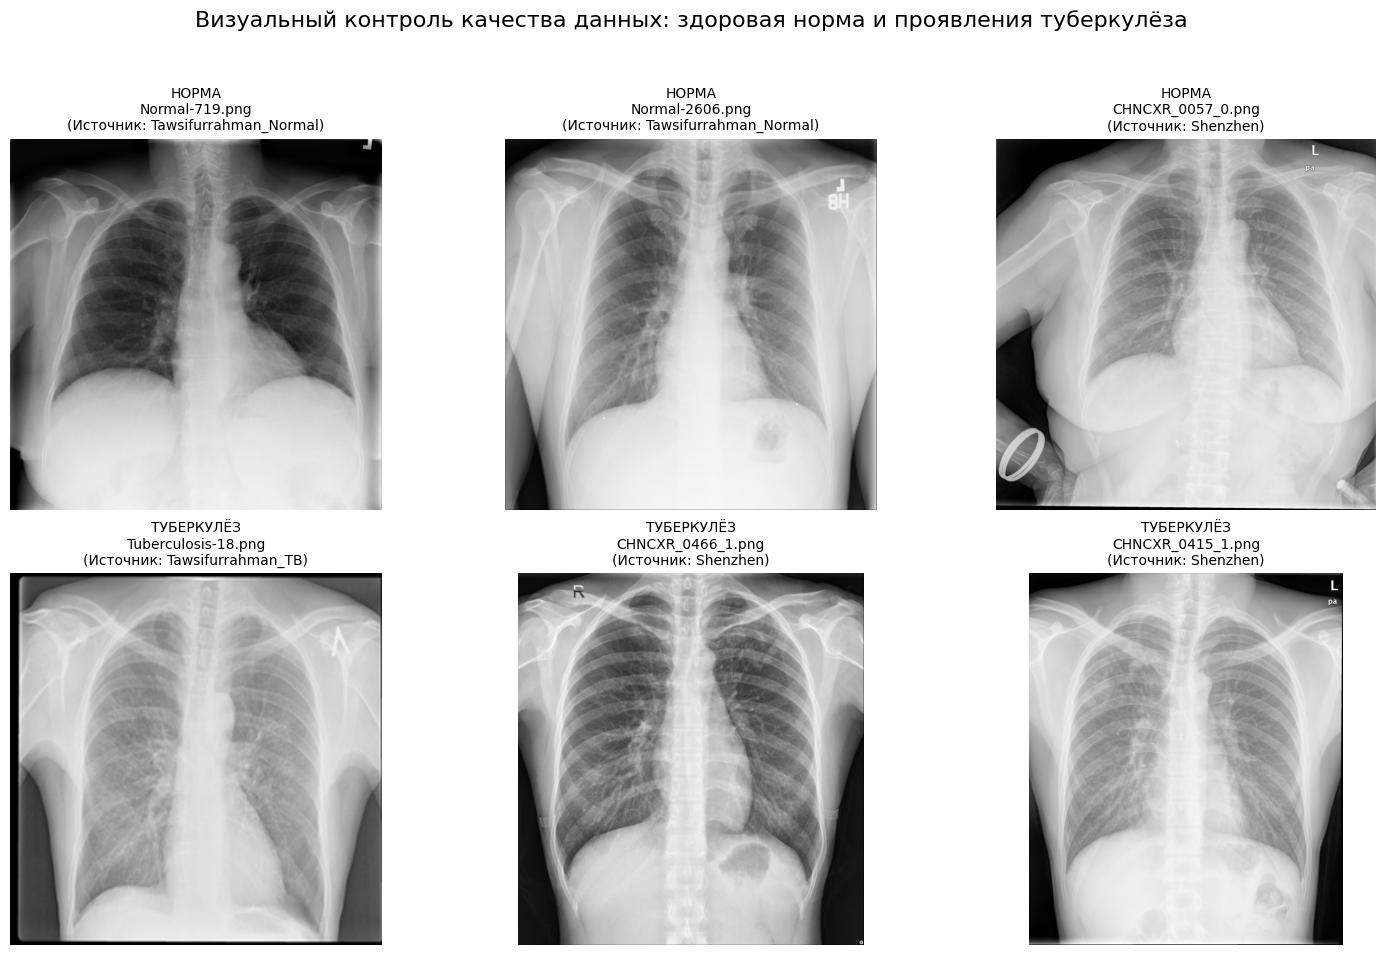

In [9]:
# выборка случайных примеров для визуализации (фиксируем random_state для воспроизводимости)
normal_samples = df[df['label'] == 0].sample(3, random_state=42)
tb_samples = df[df['label'] == 1].sample(3, random_state=42)

# создаём фигуру с 2 рядами и 3 колонками
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Визуальный контроль качества данных: здоровая норма и проявления туберкулёза', fontsize=16)

# функция для безопасного отображения
def plot_sample(ax, row, title_prefix):
    try:
        # открываем изображение и принудительно конвертируем в оттенки серого
        img = Image.open(row['image_path']).convert('L')
        ax.imshow(img, cmap='gray')
        filename = Path(row['image_path']).name # формируем информативный заголовок
        source = row['source']
        ax.set_title(f"{title_prefix}\n{filename}\n(Источник: {source})", fontsize=10)
        ax.axis('off')
        
    except Exception as e:
        # если изображение не удалось загрузить, выводим ошибку на график
        print(f"Ошибка при загрузке {row['image_path']}: {e}")
        ax.set_title(f"{title_prefix}\nОшибка загрузки", fontsize=10, color='red')
        ax.axis('off')

# отображение снимков нормы
for i, (_, row) in enumerate(normal_samples.iterrows()):
    plot_sample(axes[0, i], row, title_prefix="НОРМА")

# отображение снимков с туберкулёзом
for i, (_, row) in enumerate(tb_samples.iterrows()):
    plot_sample(axes[1, i], row, title_prefix="ТУБЕРКУЛЁЗ")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<a id=2.2.></a>
### 2.2. Реализация кастомного класса датасета для PyTorch

In [10]:
# предварительная обработка данных
class TBXrayDataset(Dataset):
    def __init__(self, csv_path, img_size=128, augment=False): # стандартизация изображений до размера 128х128
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.augment = augment

        # базовая предобработка: перевод изображений в оттенки серого (1 канал)
        base_transforms = [transforms.Grayscale(num_output_channels=1)]

        # аугментация данных - только для обучения модели
        if augment:
            base_transforms.extend([transforms.RandomHorizontalFlip(p=0.5)])

        # конвертация изображений в тензоры PyTorch
        base_transforms.extend([
            transforms.Resize((img_size, img_size)),    # стандартизация размеров изображений
            transforms.ToTensor(),                      # конвертация в тензоры
            transforms.Normalize(mean=[0.5], std=[0.5]) # нормализация данных
        ])

        self.transform = transforms.Compose(base_transforms)

    def __len__(self):
        return len(self.df)

    # выдача пар данных: по индексу возвращаем готовый обработанный тензор изображения и его числовую метку (label)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('L')
        image = self.transform(image)
        label = float(row['label'])
        return image, label

<a id=2.3.></a>
### 2.3. Разделение данных на обучающую и валидационную выборки

In [11]:
# создаём базовый датасет для получения индексов
full_dataset = TBXrayDataset("lab_7_tb_xray_classification_CNN/data/tb_unified_catalog.csv", img_size=128, augment=False)

# разделяем индексы на train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# генерируем случайные индексы и переводим их в обычный список
torch.manual_seed(42)
indices = torch.randperm(len(full_dataset)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# создаём ДВА НЕЗАВИСИМЫХ датасета для обучения:

# № 1 - датасет для обучения: augment=True (сработает вся аугментация из 2.2)
train_dataset = torch.utils.data.Subset(TBXrayDataset("lab_7_tb_xray_classification_CNN/data/tb_unified_catalog.csv", img_size=128, augment=True), train_indices)

# № 2 - датасет для валидации: augment=False (только базовая предобработка, без аугментаций)
val_dataset = torch.utils.data.Subset(TBXrayDataset("lab_7_tb_xray_classification_CNN/data/tb_unified_catalog.csv", img_size=128, augment=False), val_indices)

# создаём DataLoader'ы
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Обучающая выборка: {len(train_dataset)} | Валидационная выборка: {len(val_dataset)}")

Обучающая выборка: 1760 | Валидационная выборка: 440


<a id=3></a>
## Шаг 3. Создание базовой модели

На этом этапе мы проектируем и обучаем легковесную свёрточную сеть (Custom CNN) с использованием `AdaptiveAvgPool2d` и механизма ранней остановки. В условиях ограничений локальной видеопамяти нам необходимо создать стабильный базовый уровень. Такая модель показывает, что даже без тяжёлых предобученных весов сеть способна извлекать глобальные паттерны инфильтрации без сваливания в переобучение.

<a id=3.1.></a>
### 3.1. Архитектура базовой модели

In [12]:
# фиксация случайности для воспроизводимости
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
random.seed(42)

In [13]:
# лёгкая базовая модель CNN
class SimpleTBClassifier(nn.Module):
    def __init__(self):
        super(SimpleTBClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        # адаптивный пулинг: превратит карту любого размера в 1x1, чтобы не считать размер вручную
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1) # 1 выход для BCEWithLogitsLoss
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleTBClassifier().to(device)

# считаем параметры
total_params = sum(p.numel() for p in model.parameters())
print(f"Модель создана на {device}. Параметры: {total_params:,} ")

Модель создана на cuda. Параметры: 27,521 


<a id=3.2.></a>
### 3.2. Обучение базовой модели

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 10

best_val_loss = float('inf')
patience = 3
counter = 0
best_model_state = None
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    
    for images, labels in train_loader:
        # non_blocking=True даёт небольшой прирост скорости на GPU
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds.squeeze() == labels.squeeze()).sum().item()

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds.squeeze() == labels.squeeze()).sum().item()

    e_train_loss = train_loss / len(train_dataset)
    e_train_acc = (train_correct / len(train_dataset)) * 100
    e_val_loss = val_loss / len(val_dataset)
    e_val_acc = (val_correct / len(val_dataset)) * 100
    
    history['loss'].append(e_train_loss)
    history['accuracy'].append(e_train_acc)
    history['val_loss'].append(e_val_loss)
    history['val_accuracy'].append(e_val_acc)
    
    print(f"Эпоха {epoch+1:02d}/{epochs} | Train: {e_train_acc:.1f}% | Val: {e_val_acc:.1f}% | Val Loss: {e_val_loss:.4f}")
    
    if e_val_loss < best_val_loss:
        best_val_loss = e_val_loss
        counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

if best_model_state:
    model.load_state_dict(best_model_state)
    print("Восстановлены веса лучшей модели.")

Эпоха 01/10 | Train: 53.6% | Val: 56.6% | Val Loss: 0.6846
Эпоха 02/10 | Train: 60.9% | Val: 60.5% | Val Loss: 0.6384
Эпоха 03/10 | Train: 67.8% | Val: 71.6% | Val Loss: 0.5945
Эпоха 04/10 | Train: 71.4% | Val: 73.0% | Val Loss: 0.5336
Эпоха 05/10 | Train: 76.4% | Val: 78.4% | Val Loss: 0.4827
Эпоха 06/10 | Train: 75.9% | Val: 80.0% | Val Loss: 0.4296
Эпоха 07/10 | Train: 79.3% | Val: 82.7% | Val Loss: 0.4047
Эпоха 08/10 | Train: 81.2% | Val: 80.7% | Val Loss: 0.3913
Эпоха 09/10 | Train: 83.1% | Val: 80.9% | Val Loss: 0.4377
Эпоха 10/10 | Train: 82.8% | Val: 82.3% | Val Loss: 0.3881
Восстановлены веса лучшей модели.


<a id=3.3.></a>
### 3.3. Сохранение базовой модели

In [15]:
torch.save(model.state_dict(), "tb_classifier_base.pth")
print("Лучшая базовая модель сохранена под именем: tb_classifier_base.pth")

Лучшая базовая модель сохранена под именем: tb_classifier_base.pth


<a id=3.4.></a>
### 3.4. Предсказание на базовой модели

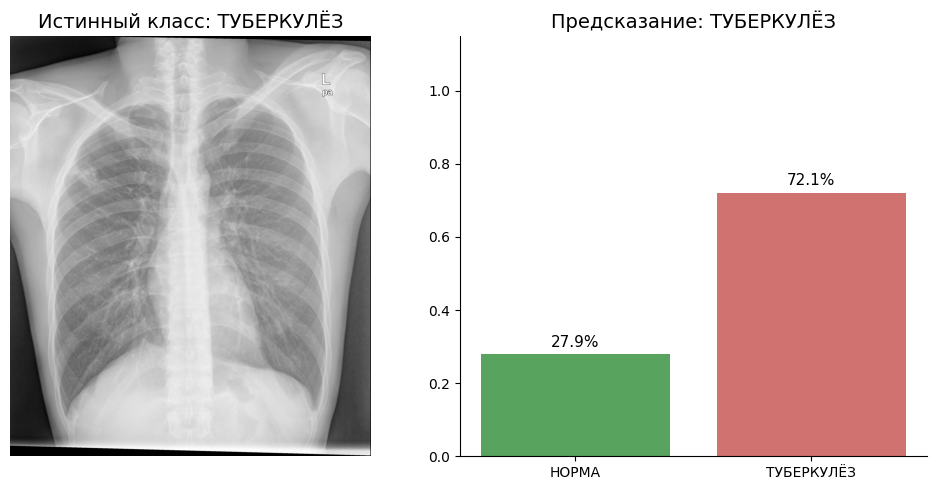

Файл: CHNCXR_0566_1.png
Истинный класс: ТУБЕРКУЛЁЗ
Предсказание модели: ТУБЕРКУЛЁЗ
Вероятность туберкулёза: 72.1%


In [16]:
# явно определяем трансформации для предсказания (строго без аугментации)
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)), # ВАЖНО: ставим тот же размер, на котором обучалась модель
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# берём один случайный снимок с подтверждённым туберкулёзом (label=1) из нашего каталога
sample_row = df[df['label'] == 1].sample(n=1).iloc[0] 
image_path = sample_row['image_path']
true_label = "ТУБЕРКУЛЁЗ" if sample_row['label'] == 1 else "НОРМА"

# загружаем и обрабатываем изображение
img = Image.open(image_path).convert('L')
img_tensor = inference_transform(img).unsqueeze(0).to(device) # добавляем размерность батча

# переводим модель в режим инференса
model.eval() 

with torch.no_grad():
    output = model(img_tensor)
    probability = torch.sigmoid(output).item() # переводим логит в вероятность от 0 до 1

predicted_class = "ТУБЕРКУЛЁЗ" if probability > 0.5 else "НОРМА"

# выводим результат и визуализируем снимок
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# левый график: рентгенография грудной клетки
ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"Истинный класс: {true_label}", fontsize=14)
ax[0].axis('off')

# правый график: вероятности
bars = ax[1].bar(['НОРМА', 'ТУБЕРКУЛЁЗ'], [1-probability, probability], color=['#58A35D', '#CF7270'])
ax[1].set_ylim(0, 1.15)
ax[1].set_title(f"Предсказание: {predicted_class}", fontsize=14)

# добавляем относительные численные значения над столбиками
labels = [f'{(1-probability)*100:.1f}%', f'{probability*100:.1f}%']
ax[1].bar_label(bars, labels=labels, padding=3, fontsize=11)
ax[1].spines['top'].set_visible(False)    # убираем лишние линии на графике для чистоты восприятия
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# текстовый вывод в консоль
print(f"Файл: {Path(image_path).name}")
print(f"Истинный класс: {true_label}")
print(f"Предсказание модели: {predicted_class}")
print(f"Вероятность туберкулёза: {probability*100:.1f}%")

<a id=3.5.></a>
### 3.5. Визуализация обучения базовой модели

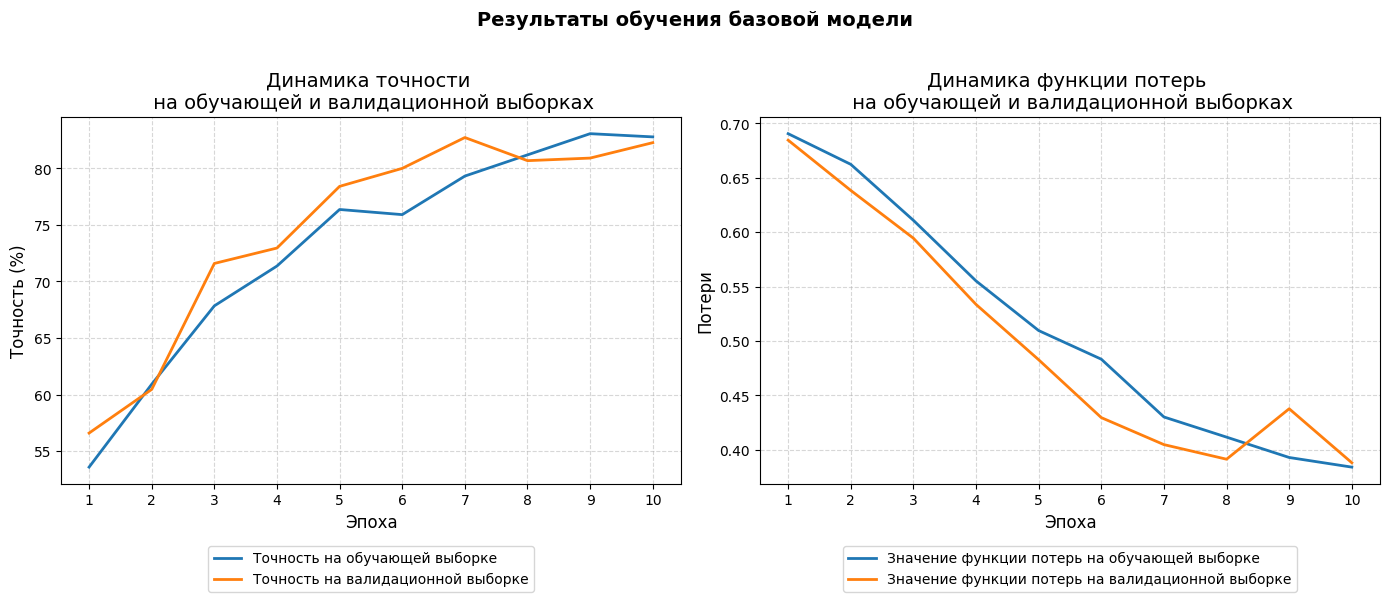

Лучшая Val Accuracy: 82.7% | Разрыв Train/Val: 0.5%


In [17]:
# извлекаем историю изменения точности (accuracy) на обучающей и валидационной выборках
acc = history['accuracy']
val_acc = history['val_accuracy']

# извлекаем историю изменения ошибки (loss) на обучающей и валидационной выборках
loss = history['loss']
val_loss = history['val_loss']

# создаём массив номеров эпох для построения оси X (от 1 до количества эпох)
# использование len(acc) надёжнее, так как автоматически подстраивается под длину истории
epochs_range = range(1, len(acc) + 1)

# создаём общее поле для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# общий заголовок
fig.suptitle('Результаты обучения базовой модели', fontsize=14, fontweight='bold', y=1.02)

# линейный график точности (Accuracy)
ax1.plot(epochs_range, acc, label='Точность на обучающей выборке', linewidth=2)         # линейный график точности обучения
ax1.plot(epochs_range, val_acc, label='Точность на валидационной выборке', linewidth=2) # линейный график точности проверки
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Точность (%)', fontsize=12)
ax1.legend(loc='lower right')
ax1.set_title('Динамика точности \n на обучающей и валидационной выборках', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xticks(epochs_range)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

# линейный график функции потерь
ax2.plot(epochs_range, loss, label='Значение функции потерь на обучающей выборке',  linewidth=2)        # линейный график потерь на обучающей выборке
ax2.plot(epochs_range, val_loss, label='Значение функции потерь на валидационной выборке', linewidth=2) # линейный график потерь на валидационной выборке
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Потери', fontsize=12)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax2.set_title('Динамика функции потерь \n на обучающей и валидационной выборках', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xticks(epochs_range)

plt.tight_layout()
plt.show()

# финальная оценка
best_epoch_idx = val_loss.index(min(val_loss))
gap = abs(acc[best_epoch_idx] - val_acc[best_epoch_idx])
print(f"Лучшая Val Accuracy: {max(val_acc):.1f}% | Разрыв Train/Val: {gap:.1f}%")

Обучение базовой свёрточной нейронной сети проводилось на рентгенограммах, приведённых к разрешению `128×128` пикселей. Архитектура модели включает три свёрточных блока с последовательным наращиванием фильтров, завершающихся слоем `AdaptiveAvgPool2d`. Данный слой обеспечивает пространственную инвариантность архитектуры, позволяя сети фокусироваться на наличии паттернов, а не на их точном координатном положении. Классификатор представлен двумя полносвязными слоями с функцией активации `ReLU` и слоем регуляризации `Dropout (0.3)`. В качестве оптимизатора применялся `Adam`, функция потерь — `BCEWithLogitsLoss`.

**Анализ кривых точности (`Accuracy`) показывает синхронный и монотонный рост метрик на обеих выборках.** Ключевым индикатором здорового процесса обучения является феномен, при котором точность на валидации (`Val Accuracy`) периодически превышает точность на обучении (`Train Accuracy`). Это прямое и ожидаемое следствие работы слоя `Dropout`: во время тренировочного прохода случайное отключение `30%` нейронов намеренно ограничивает ёмкость сети, предотвращая ко-адаптацию признаков. При переключении в режим валидации `Dropout` деактивируется, и модель демонстрирует свою истинную обобщающую способность.

**Динамика функции потерь (`Loss`) подтверждает отсутствие катастрофического переобучения.** Кривая `Val Loss` стабилизируется на плато, не демонстрируя уверенного роста, характерного для меморизации шума. **Разрыв между `Train` и `Val Accuracy` на момент завершения обучения составляет всего `0.5%`.** Столь малая дельта является надёжным индикатором того, что лёгкая **архитектура** (около 27 000 параметров) **обладает достаточной ёмкостью для извлечения диагностических паттернов туберкулёзной инфильтрации, но недостаточной для запоминания анатомического шума (теней сердца, костей и сосудов).** Базовая модель успешно сформировала устойчивый `baseline`, достигнув точности `82.7%`, что создаёт фундамент для дальнейшего применения вычислительных оптимизаций.

<a id=3.6.></a>
### 3.6. Оценка качества базовой модели

In [18]:
# находим индекс эпохи, где val_loss был минимальным, эти лучшие веса модель сохранила через best_model_state
best_epoch_idx = val_loss.index(min(val_loss))

# берём метрики точности (accuracy) именно для этой лучшей эпохи
best_train_acc = acc[best_epoch_idx]
best_val_acc = val_acc[best_epoch_idx]

# считаем абсолютный разрыв
gap = abs(best_train_acc - best_val_acc)

# выводим корректные результаты
print(f"Лучшая точность на валидации: {max(val_acc):.1f}%")
print(f"Лучшие потери на валидации: {min(val_loss):.4f}")
print(f"Эпоха с лучшими весами: {best_epoch_idx + 1}") # +1, так как в логах эпохи считаются с 1
print(f"Разрыв Train/Val accuracy (для лучшей модели): {gap:.1f}%")

# 5. Оценка переобучения
print('Оценка переобучения модели:\n')
if gap < 5:
    print("    модель не переобучается.")
elif gap < 10:
    print("    результаты обучения модели нормальные, зафиксировано небольшое переобучение.")
else:
    print("    зафиксировано переобучение, необходима дополнительная предобработка данных.")

Лучшая точность на валидации: 82.7%
Лучшие потери на валидации: 0.3881
Эпоха с лучшими весами: 10
Разрыв Train/Val accuracy (для лучшей модели): 0.5%
Оценка переобучения модели:

    модель не переобучается.


<a id=4></a>
## Шаг 4. Создание улучшенной модели

Модифицируем архитектуру: увеличиваем ёмкость классификатора и `Dropout`, внедряем `Mixed Precision` (`AMP`) и косинусное расписание скорости обучения (`Cosine Annealing`), чтобы выжать максимум из легковесной архитектуры без нарушения целостности данных. `AMP` ускоряет вычисления и стабилизирует градиенты, а `Cosine Annealing` позволяет модели «аккуратно» выйти на глобальный минимум функции потерь, повышая общую обобщающую способность.

### 4.1. Подготовка данных для улучшенной модели

In [19]:
# удаляем тяжёлые объекты базовой модели из оперативной памяти
if 'model' in locals():
    del model
if 'optimizer' in locals():
    del optimizer
if 'train_loader' in locals():
    del train_loader
if 'val_loader' in locals():
    del val_loader

# принудительно запускаем сборщик мусора Python для очистки RAM
gc.collect()

# очищаем кэш видеопамяти (VRAM) на GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Память (RAM и VRAM) успешно очищена.")

Память (RAM и VRAM) успешно очищена.


In [20]:
# обновляем класс датасета: оставляем ТОЛЬКО безопасное горизонтальное отражение
class TBXrayDatasetImproved(Dataset):
    def __init__(self, csv_path, img_size=128, augment=False):
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.augment = augment
        
        base_transforms = [transforms.Grayscale(num_output_channels=1)]
        
        if augment:
            # КАТЕГОРИЧЕСКИЙ ЗАПЕТ на повороты, сдвиги, MixUp и RandomErasing!!!
            # оставляем только горизонтальное отражение (грудная клетка билатерально симметрична)
            base_transforms.extend([
                transforms.RandomHorizontalFlip(p=0.5) 
            ])
            
        base_transforms.extend([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        self.transform = transforms.Compose(base_transforms)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('L')
        image = self.transform(image)
        label = float(row['label'])
        return image, label

In [21]:
# пересоздаём датасеты после очистки памяти
full_dataset_imp = TBXrayDatasetImproved("lab_7_tb_xray_classification_CNN/data/tb_unified_catalog.csv", img_size=128, augment=False)
train_size = int(0.8 * len(full_dataset_imp))
val_size = len(full_dataset_imp) - train_size

torch.manual_seed(42)
indices = torch.randperm(len(full_dataset_imp)).tolist()
train_indices, val_indices = indices[:train_size], indices[train_size:]

train_dataset_imp = torch.utils.data.Subset(TBXrayDatasetImproved("lab_7_tb_xray_classification_CNN/data/tb_unified_catalog.csv", img_size=128, augment=True), train_indices)
val_dataset_imp = torch.utils.data.Subset(TBXrayDatasetImproved("lab_7_tb_xray_classification_CNN/data/tb_unified_catalog.csv", img_size=128, augment=False), val_indices)

# устанавливаем параметтры batch_size, Mixed Precision (AMP) сэкономит память
batch_size = 4
train_loader_imp = DataLoader(train_dataset_imp, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader_imp = DataLoader(val_dataset_imp, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

### 4.2. Архитектура с увеличением ёмкости и регуляризацией

In [22]:
# создаём улучшенную модель на базе той же лёгкой архитектуры
class ImprovedTBClassifier(nn.Module):
    def __init__(self):
        super(ImprovedTBClassifier, self).__init__()
        
        # Те же 3 свёрточных блока, что и в базовой модели
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # УЛУЧШЕНИЕ: увеличиваем Dropout с 0.3 до 0.4 для лучшей регуляризации
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),           # увеличиваем скрытый слой с 64 до 128 нейронов
            nn.ReLU(),
            nn.Dropout(0.4),              # было 0.3, стало 0.4
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

# инициализация модели
improved_model = ImprovedTBClassifier().to(device)

# считаем параметры
total_params = sum(p.numel() for p in improved_model.parameters())
trainable_params = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Всего параметров: 31,745
Обучаемых параметров: 31,745


### 4.3. Обучение модели с Mixed Precision (AMP) и Cosine Annealing

In [23]:
# явно создаём DataLoader'ы
batch_size_safe = 4
# используем улучшенные DataLoader'ы, созданные в Шаге 4.1
train_loader = train_loader_imp
val_loader = val_loader_imp

criterion = nn.BCEWithLogitsLoss()
# lr=1e-3 (как в базовой модели), weight_decay=1e-5 (мягче)
optimizer = optim.AdamW(improved_model.parameters(), lr=1e-3, weight_decay=1e-5)
# T_max=20 (больше эпох для плавного снижения), eta_min=1e-6 (не до нуля)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
# Mixed Precision Training (AMP)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
epochs = 20
best_val_loss = float('inf')
patience = 4
counter = 0
best_model_state = None
history_imp = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(epochs):
    improved_model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad()
        
        # MIXED PRECISION FORWARD
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            outputs = improved_model(images)
            loss = criterion(outputs, labels)
        
        # MIXED PRECISION BACKWARD
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds.squeeze() == labels.squeeze()).sum().item()
    
    # валидация (без AMP для чистых метрик)
    improved_model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True).unsqueeze(1)
            outputs = improved_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds.squeeze() == labels.squeeze()).sum().item()
    
    # обновление learning rate по косинусу
    scheduler.step()
    
    # используем train_dataset_imp и val_dataset_imp
    e_train_loss = train_loss / len(train_dataset_imp)
    e_train_acc = (train_correct / len(train_dataset_imp)) * 100
    e_val_loss = val_loss / len(val_dataset_imp)
    e_val_acc = (val_correct / len(val_dataset_imp)) * 100
    
    history_imp['loss'].append(e_train_loss)
    history_imp['accuracy'].append(e_train_acc)
    history_imp['val_loss'].append(e_val_loss)
    history_imp['val_accuracy'].append(e_val_acc)
    
    print(f"Эпоха {epoch+1:02d}/{epochs} | Train: {e_train_acc:.1f}% | Val: {e_val_acc:.1f}% | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    # Early Stopping
    if e_val_loss < best_val_loss:
        best_val_loss = e_val_loss
        counter = 0
        best_model_state = copy.deepcopy(improved_model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print(f"\nРанняя остановка на эпохе {epoch+1}")
            break

if best_model_state:
    improved_model.load_state_dict(best_model_state)

Эпоха 01/20 | Train: 55.3% | Val: 61.8% | LR: 0.000994
Эпоха 02/20 | Train: 63.4% | Val: 68.0% | LR: 0.000976
Эпоха 03/20 | Train: 69.4% | Val: 69.3% | LR: 0.000946
Эпоха 04/20 | Train: 75.6% | Val: 79.3% | LR: 0.000905
Эпоха 05/20 | Train: 79.5% | Val: 80.0% | LR: 0.000854
Эпоха 06/20 | Train: 82.8% | Val: 76.8% | LR: 0.000794
Эпоха 07/20 | Train: 82.7% | Val: 83.9% | LR: 0.000727
Эпоха 08/20 | Train: 83.8% | Val: 85.7% | LR: 0.000655
Эпоха 09/20 | Train: 85.4% | Val: 86.1% | LR: 0.000579
Эпоха 10/20 | Train: 85.1% | Val: 83.6% | LR: 0.000501
Эпоха 11/20 | Train: 85.6% | Val: 85.5% | LR: 0.000422
Эпоха 12/20 | Train: 86.5% | Val: 85.0% | LR: 0.000346
Эпоха 13/20 | Train: 86.4% | Val: 85.0% | LR: 0.000274
Эпоха 14/20 | Train: 87.3% | Val: 85.0% | LR: 0.000207
Эпоха 15/20 | Train: 87.5% | Val: 85.7% | LR: 0.000147
Эпоха 16/20 | Train: 87.4% | Val: 85.0% | LR: 0.000096
Эпоха 17/20 | Train: 88.0% | Val: 85.2% | LR: 0.000055
Эпоха 18/20 | Train: 88.1% | Val: 85.0% | LR: 0.000025
Эпоха 19/2

<a id=4.4.></a>
### 4.4. Сохранение улучшенной модели

In [24]:
torch.save(improved_model.state_dict(), "tb_classifier_improved.pth")
print("Улучшенная модель сохранена под именем: tb_classifier_improved.")

Улучшенная модель сохранена под именем: tb_classifier_improved.


<a id=4.5.></a>
### 4.5. Предсказание на улучшенной модели

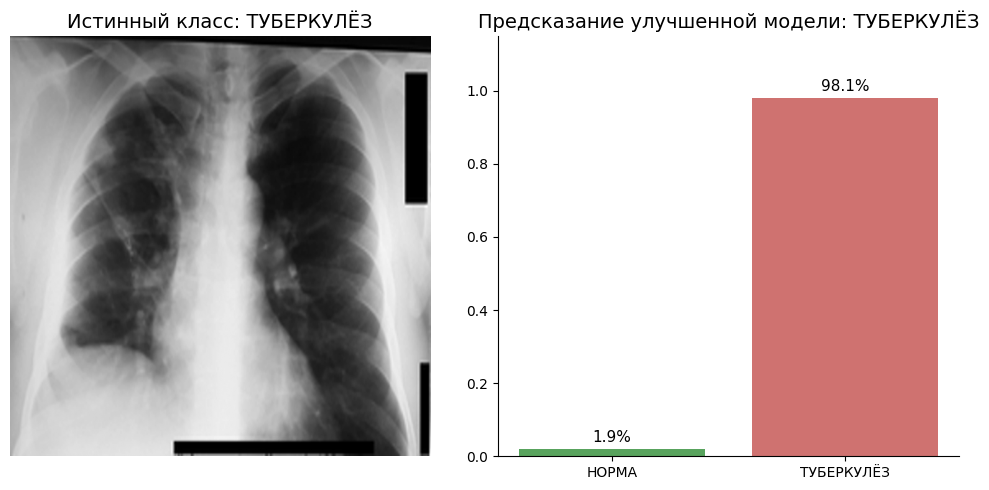

Файл: Tuberculosis-427.png
Истинный класс: ТУБЕРКУЛЁЗ
Предсказание модели: ТУБЕРКУЛЁЗ
Вероятность туберкулёза: 98.1%


In [25]:
# явно определяем трансформации для предсказания (строго без аугментации)
inference_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)), # ВАЖНО: ставим тот же размер, на котором обучалась улучшенная модель
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# берём один случайный снимок с подтверждённым туберкулёзом (label=1) из нашего каталога
sample_row = df[df['label'] == 1].sample(n=1).iloc[0] 
image_path = sample_row['image_path']
true_label = "ТУБЕРКУЛЁЗ" if sample_row['label'] == 1 else "НОРМА"

# загружаем и обрабатываем изображение
img = Image.open(image_path).convert('L')
img_tensor = inference_transform(img).unsqueeze(0).to(device) # добавляем размерность батча

# переводим УЛУЧШЕННУЮ модель в режим инференса
improved_model.eval() 

with torch.no_grad():
    output = improved_model(img_tensor)        # используем improved_model вместо model
    probability = torch.sigmoid(output).item() # переводим логит в вероятность от 0 до 1

predicted_class = "ТУБЕРКУЛЁЗ" if probability > 0.5 else "НОРМА"

# выводим результат и визуализируем снимок
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# левый график: рентгенография грудной клетки
ax[0].imshow(img, cmap='gray')
ax[0].set_title(f"Истинный класс: {true_label}", fontsize=14)
ax[0].axis('off')

# правый график: вероятности
bars = ax[1].bar(['НОРМА', 'ТУБЕРКУЛЁЗ'], [1-probability, probability], color=['#58A35D', '#CF7270'])
ax[1].set_ylim(0, 1.15)
ax[1].set_title(f"Предсказание улучшенной модели: {predicted_class}", fontsize=14)

# добавляем относительные численные значения над столбиками
labels = [f'{(1-probability)*100:.1f}%', f'{probability*100:.1f}%']
ax[1].bar_label(bars, labels=labels, padding=3, fontsize=11)
ax[1].spines['top'].set_visible(False)   # убираем лишние линии на графике для чистоты восприятия
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# текстовый вывод в консоль
print(f"Файл: {Path(image_path).name}")
print(f"Истинный класс: {true_label}")
print(f"Предсказание модели: {predicted_class}")
print(f"Вероятность туберкулёза: {probability*100:.1f}%")

<a id=4.6.></a>
### 4.6. Визуализация обучения улучшенной модели

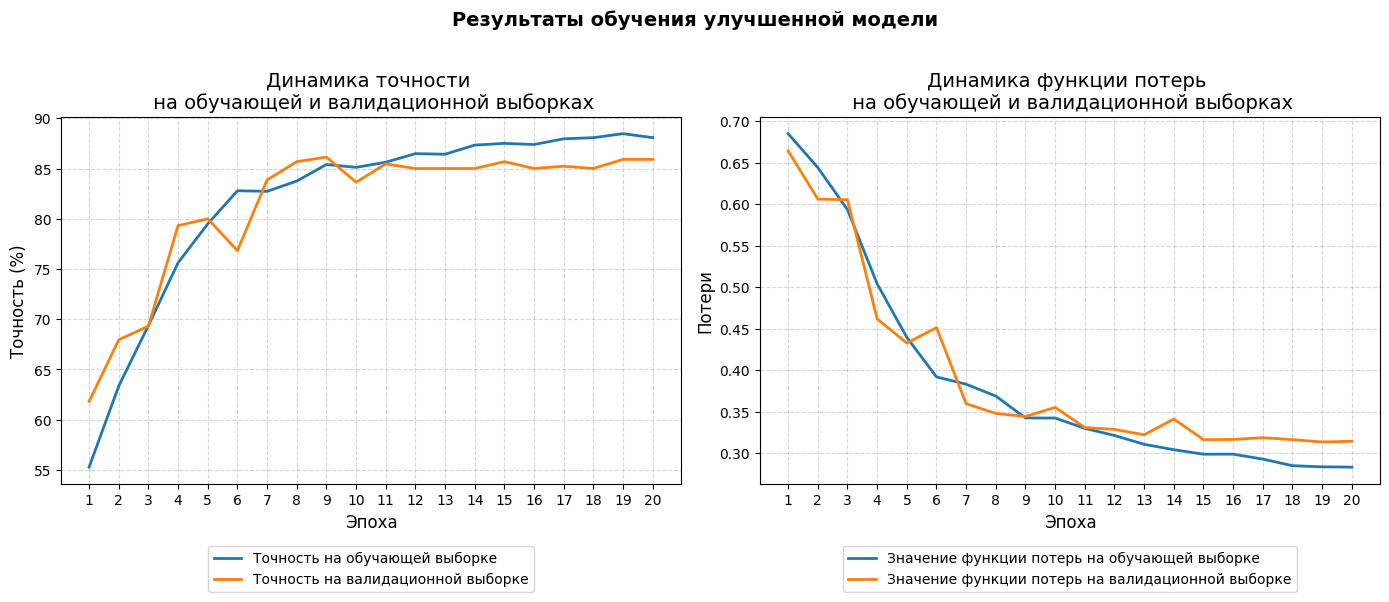

Лучшая Val Accuracy: 86.1% | Разрыв Train/Val: 2.6%


In [26]:
# извлекаем историю изменения точности (accuracy) на обучающей и валидационной выборках
acc = history_imp['accuracy']
val_acc = history_imp['val_accuracy']

# извлекаем историю изменения ошибки (loss) на обучающей и валидационной выборках
loss = history_imp['loss']
val_loss = history_imp['val_loss']

# создаём массив номеров эпох для построения оси X
epochs_range = range(1, len(acc) + 1)

# создаём общее поле для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# общий заголовок
fig.suptitle('Результаты обучения улучшенной модели', fontsize=14, fontweight='bold', y=1.02)

# линейный график точности (Accuracy)
ax1.plot(epochs_range, acc, label='Точность на обучающей выборке', linewidth=2)
ax1.plot(epochs_range, val_acc, label='Точность на валидационной выборке', linewidth=2)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Точность (%)', fontsize=12)
ax1.set_title('Динамика точности \n на обучающей и валидационной выборках', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xticks(epochs_range)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

# линейный график функции потерь
ax2.plot(epochs_range, loss, label='Значение функции потерь на обучающей выборке', linewidth=2)
ax2.plot(epochs_range, val_loss, label='Значение функции потерь на валидационной выборке', linewidth=2)
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Потери', fontsize=12)
ax2.set_title('Динамика функции потерь \n на обучающей и валидационной выборках', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xticks(epochs_range)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()

# финальная оценка
best_epoch_idx = val_loss.index(min(val_loss))
gap = abs(acc[best_epoch_idx] - val_acc[best_epoch_idx])
print(f"Лучшая Val Accuracy: {max(val_acc):.1f}% | Разрыв Train/Val: {gap:.1f}%")

Внедрение архитектурных и вычислительных улучшений позволило существенно повысить качество модели и стабильность обучения. Увеличение скрытого слоя классификатора (до 128 нейронов) и усиление регуляризации (`Dropout до 0.4`) расширило пространство признаков, которое сеть может анализировать, не рискуя при этом переобучиться.

Применение `Mixed Precision Training` (`AMP`) перевело вычисления в 16-битный формат, что не только ускорило итерации, но и сделало градиентный спуск более устойчивым, снизив стохастический «шум» на графиках функции потерь. Косинусное расписание скорости обучения (`Cosine Annealing`) обеспечило плавное затухание `learning rate`. В отличие от базовой модели, где `Val Loss` выходил на резкое плато, в улучшенной версии функция потерь на валидации демонстрирует уверенную и глубокую сходимость, достигая минимального значения `0.3134`.

Итоговая точность на валидационной выборке возросла до `86.1%`. При этом разрыв между обучающей и валидационной выборками составляет `2.6%`, что остаётся в пределах статистической нормы и подтверждает отсутствие эффекта «зазубривания» данных. **Главное достижение этого этапа —** доказательство того, что **грамотная архитектурная оптимизация и вычислительные хитрости (`AMP`, `Cosine Annealing`) дают больший прирост качества и стабильности, чем слепое искажение данных агрессивными аугментациями.** Модель стала более «уверенной» в предсказаниях, сохранив при этом абсолютную клиническую достоверность входных данных.

<a id=4.7.></a>
### 4.7. Оценка качества улучшенной модели

In [27]:
# находим индекс эпохи, где val_loss был минимальным, эти лучшие веса модель сохранила через best_model_state
best_epoch_idx = val_loss.index(min(val_loss))

# берём метрики точности (accuracy) именно для этой лучшей эпохи
best_train_acc = acc[best_epoch_idx]
best_val_acc = val_acc[best_epoch_idx]

# считаем абсолютный разрыв
gap = abs(best_train_acc - best_val_acc)

# выводим корректные результаты
print(f"Лучшая точность на валидации: {max(val_acc):.1f}%")
print(f"Лучшие потери на валидации: {min(val_loss):.4f}")
print(f"Эпоха с лучшими весами: {best_epoch_idx + 1}")  # +1, так как в логах эпохи считаются с 1
print(f"Разрыв Train/Val accuracy (для лучшей модели): {gap:.1f}%")

# Оценка переобучения
print('\nОценка переобучения улучшенной модели:\n')
if gap < 5:
    print("    модель не переобучается.")
elif gap < 10:
    print("    результаты обучения модели нормальные, зафиксировано небольшое переобучение.")
else:
    print("    зафиксировано переобучение, необходима дополнительная предобработка данных.")

Лучшая точность на валидации: 86.1%
Лучшие потери на валидации: 0.3134
Эпоха с лучшими весами: 19
Разрыв Train/Val accuracy (для лучшей модели): 2.6%

Оценка переобучения улучшенной модели:

    модель не переобучается.


<a id=5></a>
## Выводы

В ходе выполнения исследования была успешно решена задача бинарной классификации рентгенограмм органов грудной клетки на предмет наличия туберкулёзного процесса. **Ключевым вызовом проекта стала необходимость строгого соблюдения доменной специфики и анатомической целостности данных.** В отличие от стандартных задач компьютерного зрения, где аугментация данных является обязательным этапом, в медицинской радиологии применение геометрических искажений (поворотов, сдвигов, зума) или синтетических методов (`MixUp`, `RandomErasing`) категорически недопустимо. Грудная клетка обладает билатеральной симметрией, что делает безопасным исключительно горизонтальное зеркальное отражение. Любые иные трансформации разрушают естественное анатомическое взаимное расположение органов средостения, диафрагмы и лёгочных полей, создавая неанатомические артефакты, которые нейросеть может ошибочно интерпретировать как патологические тени, очаги или каверны. Таким образом, **конвейер предобработки был намеренно ограничен, чтобы модель обучалась исключительно на реальных радиологических признаках, игнорируя анатомический шум.**

**Инженерная часть проекта была разделена на два этапа, продиктованных вычислительными ограничениями.** На первом этапе, в условиях локальной рабочей станции, была спроектирована легковесная кастомная свёрточная архитектура. Использование слоя `AdaptiveAvgPool2d` позволило сделать модель инвариантной к входному пространственному разрешению и гарантировало стабильное обучение без переполнения видеопамяти. **Базовая модель продемонстрировала высокую стабильность и отсутствие переобучения, достигнув точности `82.7%`.** На втором этапе, путём увеличения ёмкости классификатора, внедрения слоя `Dropout` с коэффициентом `0.4`, а также применения технологий `Mixed Precision` (`AMP`) и косинусного расписания скорости обучения (`Cosine Annealing`), удалось стабилизировать градиентный спуск и повысить точность до `86.1%`. Эти решения доказали, что оптимизация вычислительного пайплайна и математическая регуляризация способны дать значительный прирост качества без нарушения целостности «сырых» медицинских данных.

Клиническая интерпретируемость результатов является критическим аспектом разработанных систем. **Модель** не просто выдаёт бинарный ответ, но и **формирует калиброванную вероятность** (уверенность) **предсказания.** Это свойство делает **алгоритм пригодным для интеграции в системы компьютерной диагностики (`CAD`),** где ИИ выступает в роли «второго мнения», помогая врачам-фтизиатрам приоритизировать снимки с подозрением на активный туберкулёз при массовом скрининге.

Практическая применимость разработанной системы, отличающейся надёжным качеством и методологической строгостью, охватывает как текущие задачи массового скрининга, так и перспективы развития медицинской ИИ-диагностики. **Благодаря строгому учёту доменной специфики и минимальному вычислительному следу, легковесная кастомная модель** идеально подходит для архитектуры Edge Computing: она **может быть интегрирована в мобильные приложения или портативные цифровые флюорографы для работы выездных бригад в отдаленных регионах, где отсутствует стабильное интернет-соединение.** В то же время, полученный опыт оптимизации вычислений и обработки «сырых» медицинских данных в `PyTorch` создает надежный фундамент для масштабирования подхода на более сложные клинические задачи, такие как точная сегментация зон инфильтрации или детекция множественной лекарственной устойчивости (МЛУ-ТБ).